In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
from Tracer.solvers import solver_rk45, solver_euler

## Investigating the difference between log and uniform wind

In [22]:
# Contents

#1. Simulator
#   - setup                        | playfield-, basis shot-, and wind parameters)
#   - parameter library            | designing which values for each param should be tested)
#   - run_simulation()             | Runs the trajectory model with given inputs
#   - percent_distance_error()     | Calculates the distance betweem landing points, normalized)
#   - varying_parameter()          | Takes a parameter from the library and plots the resulting trajectories and errors
#   - varying_two_parameters()     | Takes two parameters and makes a heatplot of the error

### Simulator

In [ ]:
# Rans file
datafile = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'

# play field parameters - dont touch unless necessary
P0=np.array([0, 0, 0])
nx = 500        # length of play field
ny = 200        # width of play field
nz = 100        # height of play field
dt = 0.01       # time step

# Basis shot parameters - if not otherwise specified, these are used
shot_speed = 76.44384   # intital velocity
shot_angle = 10.4       # initial angle for trajectory	
shot_spin = 2545        # initial spin

spin_axis = 0

design_n = 10
def include_baseline(values, baseline, design_n=design_n):
    """
    Ensures baseline is included while keeping exactly n_total samples.
    Replaces the nearest sampled value if baseline is not already present.
    """
    values = np.array(values)

    # if baseline already exists, just return sorted values
    if np.isclose(values, baseline).any():
        return np.sort(values)

    # find nearest existing point and replace it
    idx = np.argmin(np.abs(values - baseline))
    values[idx] = baseline

    return np.sort(values)

# Basis wind parameters - if not otherwise specified, these are used
U_ref = 6       # reference wind speed at 10 meters above ground (6 m/s is approx. danish average)
z0 = 0.003       # surface roughness
direction = 0   # wind direction (0 is tailwind, 180 is headwind)

baseline_values = {
    "shot_speed": shot_speed,
    "shot_angle": shot_angle,
    "shot_spin": shot_spin,
    "U_ref": U_ref,
    "z0": z0,
    "direction": direction
}

design_n = 10

parameter_library = {
    "shot_speed": {
        "values": include_baseline(np.linspace(35, 85, design_n), shot_speed),
        "name": "Shot speed",
        "unit": "m/s"
    },
    "shot_angle": {
        "values": include_baseline(np.linspace(5, 25, design_n), shot_angle),
        "name": "Shot angle",
        "unit": "deg"
    },
    "shot_spin": {
        "values": include_baseline(np.linspace(2000, 10000, design_n), shot_spin),
        "name": "Shot spin",
        "unit": "rpm"
    },
    "U_ref": {
        "values": include_baseline(np.linspace(2, 10, design_n), U_ref),
        "name": "Wind speed",
        "unit": "m/s"
    },
    "z0": {
        "values": include_baseline(np.logspace(np.log10(0.001), np.log10(1), design_n), z0),
        "name": "Roughness",
        "unit": "m"
    },
    "direction": {
        "values": include_baseline(np.linspace(0, 180, design_n), direction),
        "name": "Wind direction",
        "unit": "deg"
    }
}

In [25]:
# ============================================================
# --- Simulation ---
# ============================================================

def run_simulation(shot_speed=shot_speed, shot_angle=shot_angle,
                   shot_spin=shot_spin, U_ref=U_ref,
                   z0=z0, direction=direction):

    # trajectory with log wind
    log_wind = WindField(profile='rans', ds=datafile,U_ref=U_ref)
    log_trajectory = Trajectory(ball_speed=shot_speed, launch_angle=shot_angle, spin_rate=shot_spin, spin_axis=spin_axis,wind=log_wind)
    log_trajectory.solve(solver='euler', dt=dt)
    log_p = log_trajectory.p

    # trajectory with uniform wind
    uni_wind = WindField(direction=direction, profile='log', U_ref=U_ref, z0=z0, z_ref=z_ref)
    uni_trajectory = Trajectory(ball_speed=shot_speed, launch_angle=shot_angle, spin_rate=shot_spin, spin_axis=spin_axis,wind=uni_wind)
    uni_trajectory.solve(solver='euler',dt=dt)
    uni_p = uni_trajectory.p

    return log_p, uni_p


# ============================================================
# --- Baseline Detector ---
# ============================================================

def is_baseline(param_key, value, tol=1e-8):
    return np.isclose(value, baseline_values[param_key], atol=tol)


# ============================================================
# --- Universal Parameter Formatter ---
# ============================================================

def format_param(v):
    if v == 0:
        return "0"
    elif abs(v) < 1e-2:
        return f"{v:.2e}"
    elif abs(v) >= 1000:
        return f"{v:.0f}"
    elif abs(v) >= 1:
        return f"{v:.2f}".rstrip('0').rstrip('.')
    else:
        return f"{v:.4f}".rstrip('0').rstrip('.')


# ============================================================
# --- Error Models ---
# ============================================================

def percent_distance_error(log_p, uni_p):
    dx = uni_p[-1, 0] - log_p[-1, 0]
    dy = uni_p[-1, 1] - log_p[-1, 1]
    norm = np.sqrt((log_p[-1, 0]-log_p[0, 0])**2 + (log_p[-1, 1]-log_p[0, 1])**2)
    return np.sqrt(dx**2 + dy**2) / norm * 100

def distance_error(log_p, uni_p):
    dx = uni_p[-1, 0] - log_p[-1, 0]
    dy = uni_p[-1, 1] - log_p[-1, 1]
    return np.sqrt(dx**2 + dy**2)

def x_distance_error(log_p, uni_p):
    return uni_p[-1, 0] - log_p[-1, 0]

def y_distance_error(log_p, uni_p):
    return uni_p[-1, 1] - log_p[-1, 1]


# ============================================================
# --- Varying One Parameter ---
# ============================================================

def varying_parameter(param_key, shot_speed=shot_speed, shot_angle=shot_angle,
                      shot_spin=shot_spin, U_ref=U_ref,
                      z0=z0, direction=direction):

    p = parameter_library[param_key]
    param = p["values"]

    param_results = []
    param_errors = []
    param_abs_errors = []
    param_x_errors = []
    param_y_errors = []

    for value in param:

        kwargs = {
            "shot_speed": shot_speed,
            "shot_angle": shot_angle,
            "shot_spin": shot_spin,
            "U_ref": U_ref,
            "z0": z0,
            "direction": direction
        }

        kwargs[param_key] = value

        log_p, uni_p = run_simulation(**kwargs)

        param_results.append((log_p, uni_p))
        param_errors.append(percent_distance_error(log_p, uni_p))
        param_abs_errors.append(distance_error(log_p, uni_p))
        param_x_errors.append(x_distance_error(log_p, uni_p))
        param_y_errors.append(y_distance_error(log_p, uni_p))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax1, ax2, ax3, ax4 = axes.flatten()
    colors = plt.cm.viridis(np.linspace(0, 1, len(param_results)))

    # --- 1. Trajectories ---
    for i, (log_p, uni_p) in enumerate(param_results):

        if is_baseline(param_key, param[i]):
            ax1.plot(log_p[:, 0], log_p[:, 2],
                     color='black', linewidth=3,
                     label=f"Baseline RANS ({format_param(param[i])} {p['unit']})")

            ax1.plot(uni_p[:, 0], uni_p[:, 2], '--',
                     color='black', linewidth=3,
                     label=f"Baseline Log ({format_param(param[i])} {p['unit']})")
        else:
            ax1.plot(log_p[:, 0], log_p[:, 2],
                     color=colors[i],
                     label=f"RANS, {format_param(param[i])} {p['unit']}")

            ax1.plot(uni_p[:, 0], uni_p[:, 2], '--',
                     color=colors[i],
                     label=f"Log, {format_param(param[i])} {p['unit']}")

    ax1.set_xlabel("Length (m)")
    ax1.set_ylabel("Height (m)")
    ax1.set_title(f"Trajectories with varying {p['name']}")
    ax1.legend(loc='center right', bbox_to_anchor=(-0.15, 0.5), fontsize=8)

    # --- 2. Percent Error ---
    ax2.plot(param, param_errors, color='gray')

    for i in range(len(param)):
        if is_baseline(param_key, param[i]):
            ax2.scatter(param[i], param_errors[i],
                        color='black', marker='x', s=120, linewidths=3,
                        zorder=5, label='Baseline')
        else:
            ax2.scatter(param[i], param_errors[i], color=colors[i])

    ax2.set_xlabel(f"{p['name']} ({p['unit']})")
    ax2.set_ylabel("Landing position deviation (%)")
    ax2.set_title(f"% Error vs {p['name']}")
    ax2.set_xticks(param)
    ax2.set_xticklabels([format_param(v) for v in param], rotation=30)
    ax2.grid()

    # --- 3. X vs Y Error ---
    for i in range(len(param)):
        if is_baseline(param_key, param[i]):
            ax3.scatter(param_y_errors[i], param_x_errors[i],
                        color='black', marker='x', s=120, linewidths=3,
                        label='Baseline')
        else:
            ax3.scatter(param_y_errors[i], param_x_errors[i],
                        color=colors[i],
                        label=f"{format_param(param[i])} {p['unit']}")

        ax3.text(param_y_errors[i], param_x_errors[i],
                 format_param(param[i]), fontsize=8)

    ax3.axhline(0, linestyle='--')
    ax3.axvline(0, linestyle='--')
    ax3.set_xlabel("Y error (m)")
    ax3.set_ylabel("X error (m)")
    ax3.set_title("Directional Error (Y vs X)")
    ax3.grid()

    # --- 4. Absolute Error ---
    ax4.plot(param, param_abs_errors, color='gray')

    for i in range(len(param)):
        if is_baseline(param_key, param[i]):
            ax4.scatter(param[i], param_abs_errors[i],
                        color='black', marker='x', s=120, linewidths=3,
                        zorder=5, label='Baseline')
        else:
            ax4.scatter(param[i], param_abs_errors[i], color=colors[i])

    ax4.set_xlabel(f"{p['name']} ({p['unit']})")
    ax4.set_ylabel("Landing position deviation (m)")
    ax4.set_title(f"Absolute Error vs {p['name']}")
    ax4.set_xticks(param)
    ax4.set_xticklabels([format_param(v) for v in param], rotation=30)
    ax4.grid()

    plt.tight_layout()
    plt.show()


# ============================================================
# --- Varying Two Parameters ---
# ============================================================

def varying_two_parameters(param1_key, param2_key,
                           shot_speed=shot_speed, shot_angle=shot_angle,
                           shot_spin=shot_spin, U_ref=U_ref,
                           z0=z0, direction=direction):

    p1 = parameter_library[param1_key]
    p2 = parameter_library[param2_key]

    param1 = p1["values"]
    param2 = p2["values"]

    error_grid_percent = []
    error_grid = []

    for val1 in param1:
        row_errors_percent = []
        row_errors = []

        for val2 in param2:

            kwargs = {
                "shot_speed": shot_speed,
                "shot_angle": shot_angle,
                "shot_spin": shot_spin,
                "U_ref": U_ref,
                "z0": z0,
                "direction": direction
            }

            kwargs[param1_key] = val1
            kwargs[param2_key] = val2

            log_p, uni_p = run_simulation(**kwargs)

            row_errors_percent.append(percent_distance_error(log_p, uni_p))
            row_errors.append(distance_error(log_p, uni_p))

        error_grid_percent.append(row_errors_percent)
        error_grid.append(row_errors)

    error_grid_percent = np.array(error_grid_percent)
    error_grid = np.array(error_grid)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Heatmap ---
    im = ax1.imshow(error_grid_percent, origin='lower', aspect='auto', vmin=0, vmax=16)

    base1 = baseline_values[param1_key]
    base2 = baseline_values[param2_key]

    i_base = np.where(np.isclose(param1, base1))[0][0]
    j_base = np.where(np.isclose(param2, base2))[0][0]

    ax1.scatter(j_base, i_base,
                color='black', marker='x', s=200, linewidths=3,
                label='Baseline')

    cbar = plt.colorbar(im, ax=ax1)
    cbar.set_label("Landing position deviation (%)")

    ax1.set_xticks(range(len(param2)))
    ax1.set_yticks(range(len(param1)))
    ax1.set_xticklabels([format_param(v) for v in param2], rotation=30)
    ax1.set_yticklabels([format_param(v) for v in param1])

    ax1.set_xlabel(f"{p2['name']} ({p2['unit']})")
    ax1.set_ylabel(f"{p1['name']} ({p1['unit']})")
    ax1.set_title(f"{p1['name']} vs {p2['name']}")

    # --- 2D line plot ---
    colors = plt.cm.viridis(np.linspace(0, 1, len(param1)))

    for i, val1 in enumerate(param1):
        ax2.plot(param2, error_grid[i, :],
                 marker='o',
                 color=colors[i],
                 label=f"{p1['name']}={format_param(val1)} {p1['unit']}")

    ax2.scatter(param2[j_base], error_grid[i_base, j_base],
                color='black',
                marker='x',
                s=150,
                linewidths=3,
                zorder=5,
                label='Baseline')

    ax2.set_xlabel(f"{p2['name']} ({p2['unit']})")
    ax2.set_ylabel("Landing position deviation (m)")
    ax2.set_title(f"Error vs {p2['name']} (for varying {p1['name']})")
    ax2.set_xticks(param2)
    ax2.set_xticklabels([format_param(v) for v in param2], rotation=30)
    ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    ax2.grid()

    plt.tight_layout()
    plt.show()

## Single variable variations

### Shot input variations: Shot speed, Shot angle, Shot spin

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with p

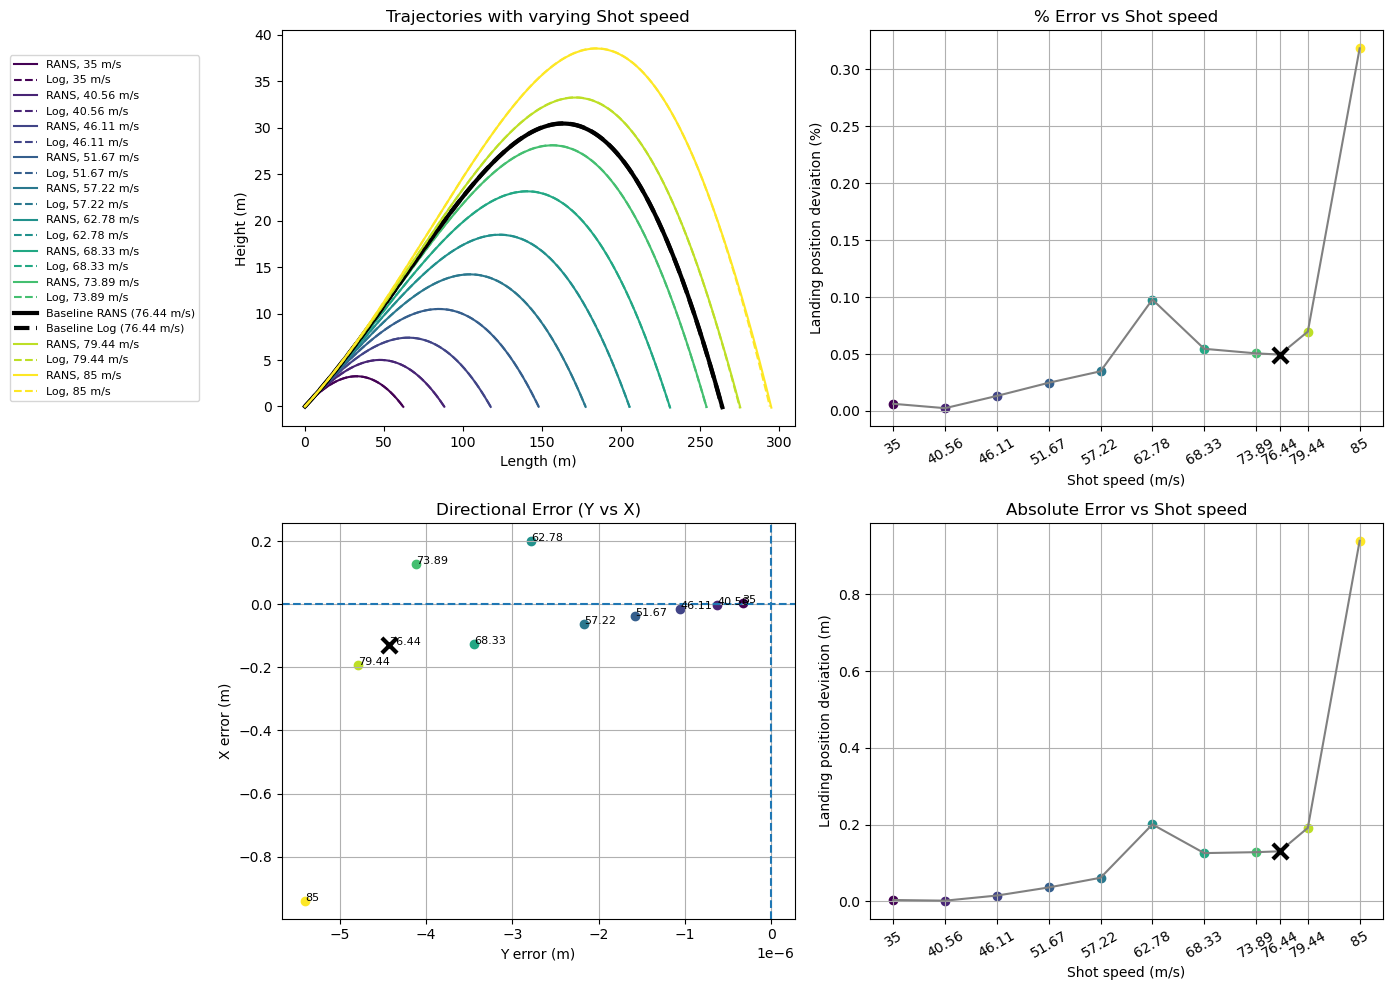

In [26]:
varying_parameter("shot_speed")

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with p

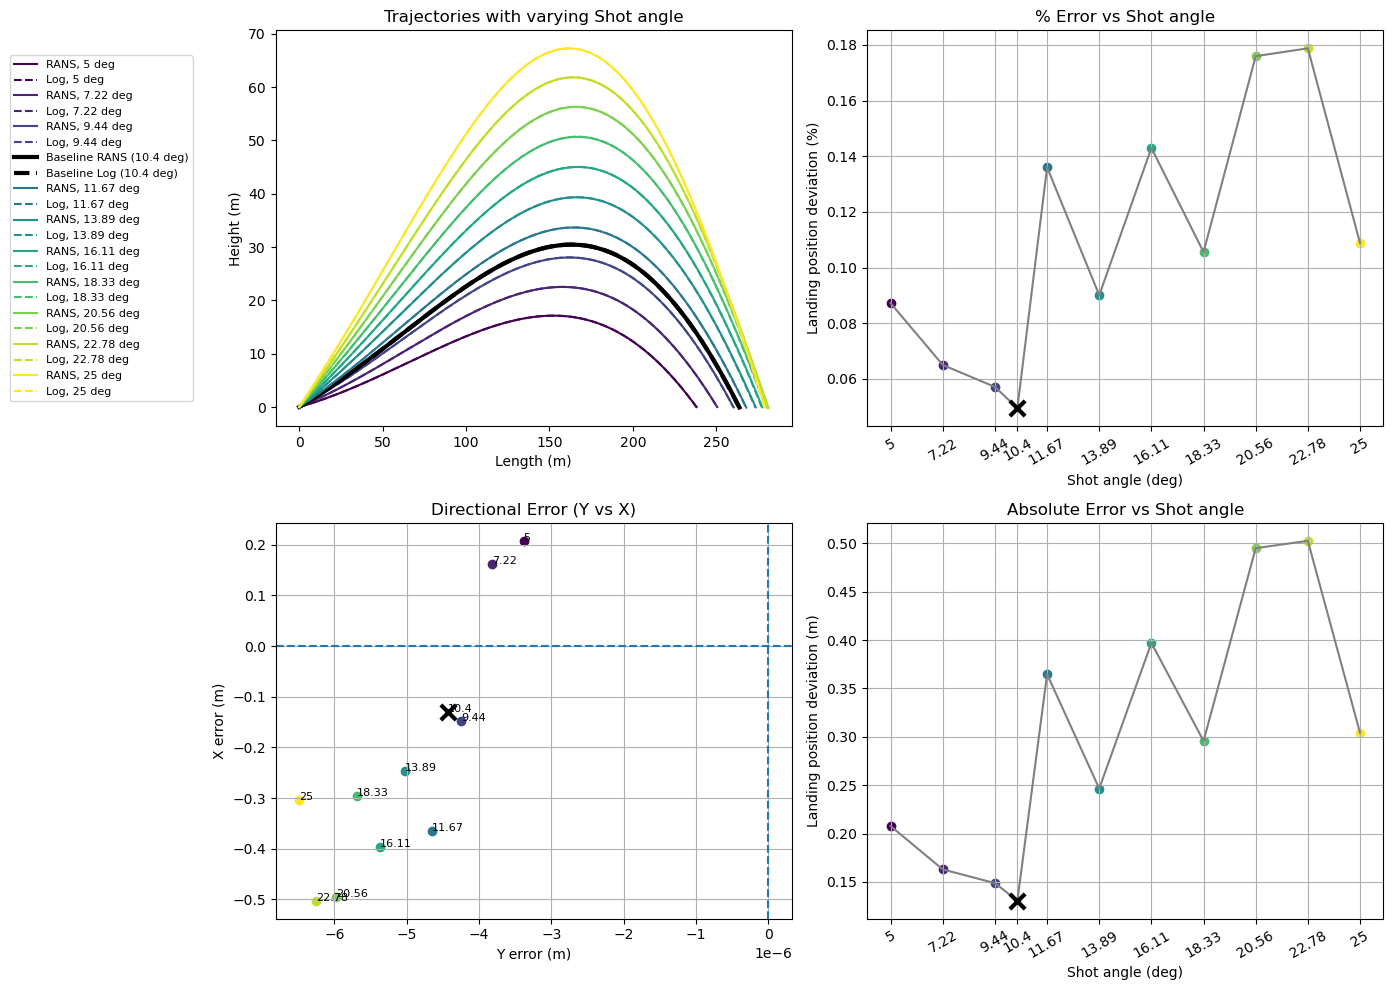

In [27]:
varying_parameter("shot_angle")

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with p

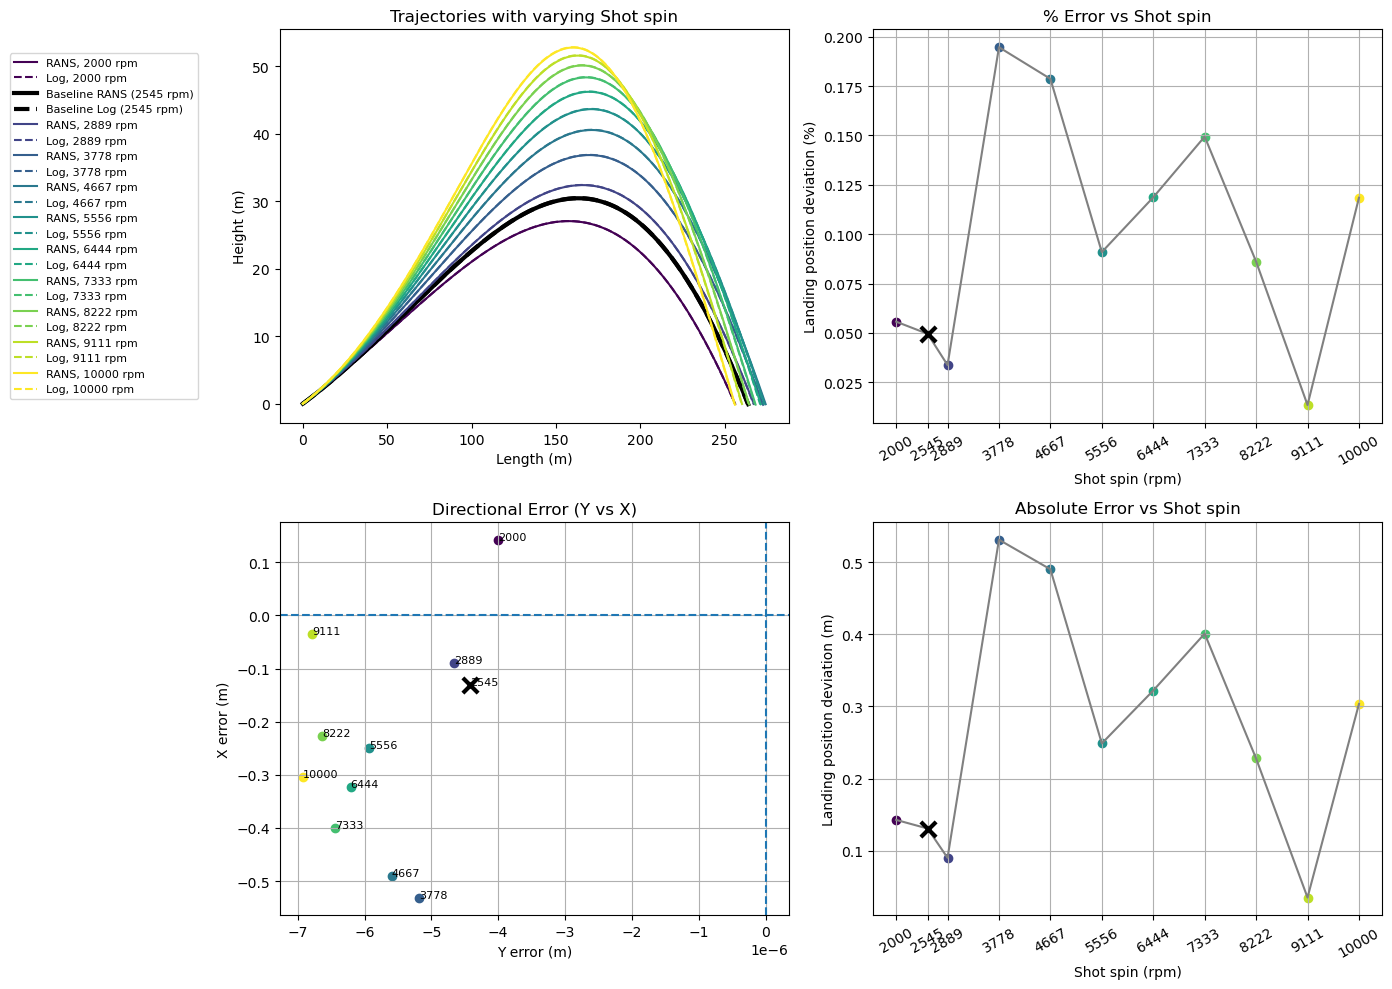

In [28]:
varying_parameter("shot_spin")

### Wind input variations: Wind speed, roughness, wind direction

In [ ]:
varying_parameter("U_ref")

In [ ]:
varying_parameter("z0")

In [ ]:
varying_parameter("direction")

## Changing multiple parameters

### Simulator and library

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with p

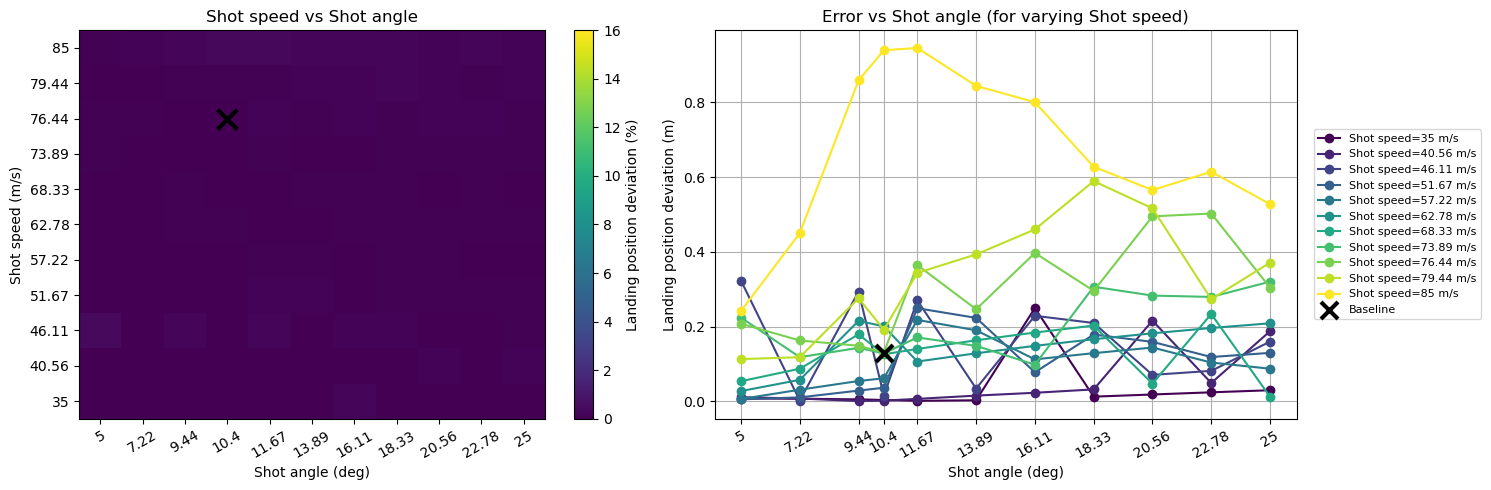

In [29]:
varying_two_parameters("shot_speed", "shot_angle")

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with p

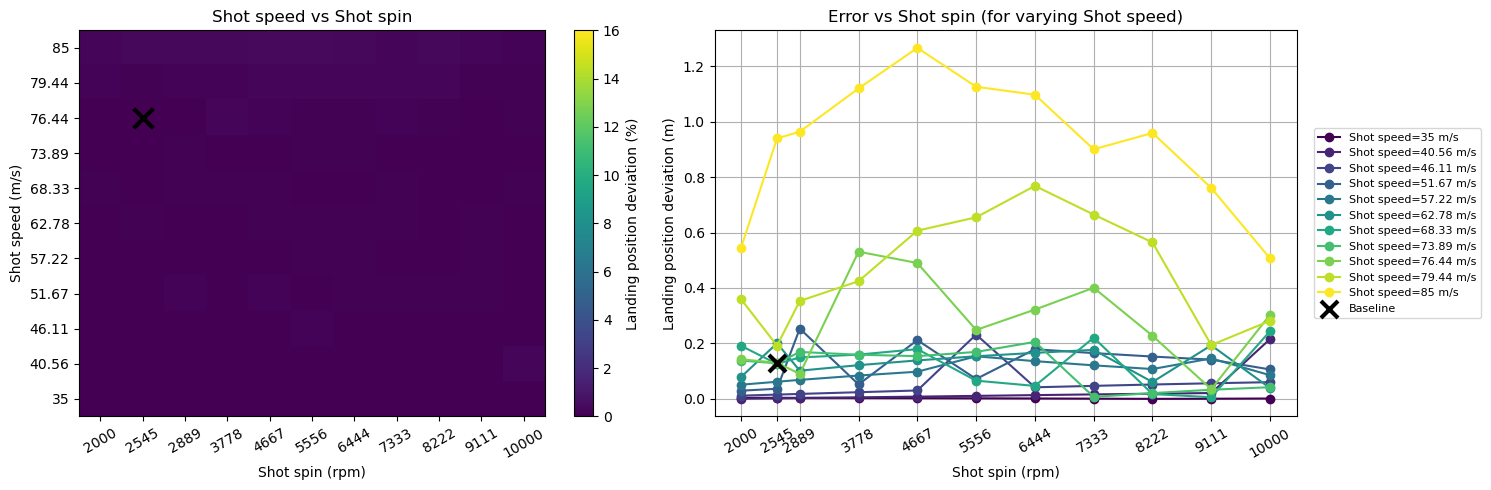

In [30]:
varying_two_parameters("shot_speed", "shot_spin")

In [ ]:
varying_two_parameters("shot_speed", "U_ref")

In [ ]:
varying_two_parameters("shot_speed", "z0")

In [ ]:
varying_two_parameters("shot_speed", "direction")

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.003, z_ref=10
Synthesizing wind field with p

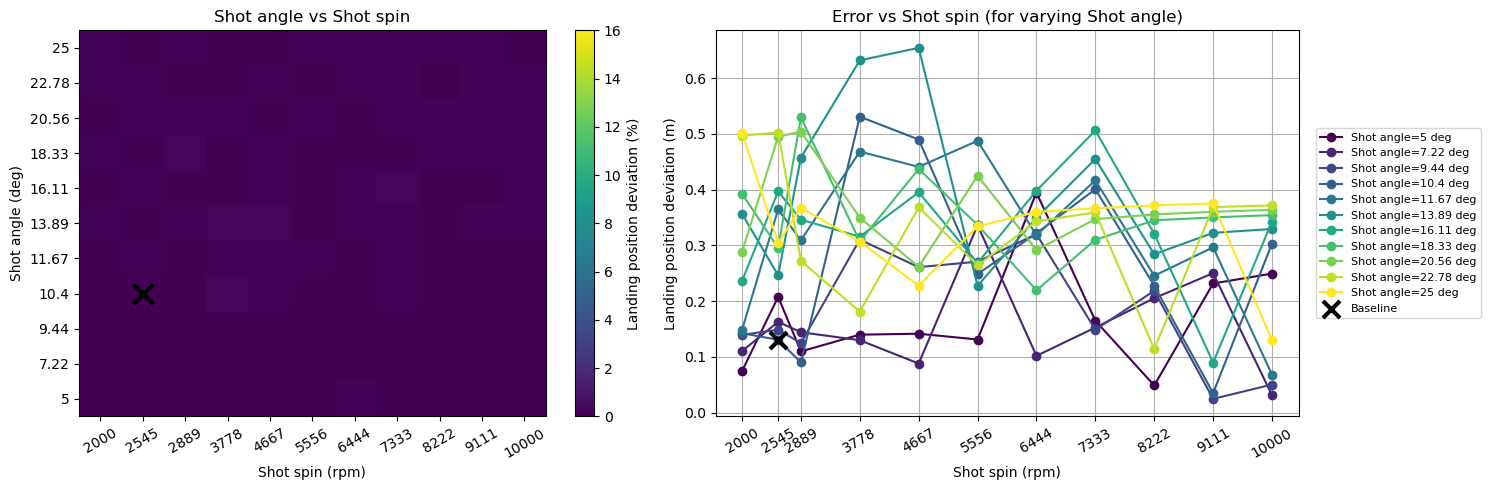

In [31]:
varying_two_parameters("shot_angle", "shot_spin")

In [ ]:
varying_two_parameters("shot_angle", "U_ref")

In [ ]:
varying_two_parameters("shot_angle", "z0")

In [ ]:
varying_two_parameters("shot_angle", "direction")

In [ ]:
varying_two_parameters("shot_spin", "U_ref")

In [ ]:
varying_two_parameters("shot_spin", "z0")

In [ ]:
varying_two_parameters("shot_spin", "direction")

In [ ]:
varying_two_parameters("U_ref", "z0")

In [ ]:
varying_two_parameters("U_ref", "direction")

In [ ]:
varying_two_parameters("z0", "direction")